Example for the usage of pyspectrum in loading data files into spectrum. 
this will include two types of data files - 
1. channel-counts
2. time-channel type files into Spectrum

In [1]:
from pyspectrum.core import Spectrum
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

channel- counts

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
spectrum['channel'] = spectrum.index 

spectrum = Spectrum.from_dataframe(df=spectrum, channel_col="channel", counts_col="counts")


Text(0, 0.5, 'counts')

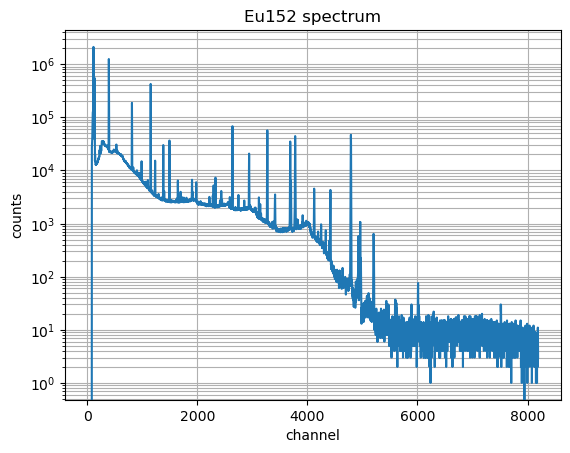

In [3]:
spectrum.xr_spectrum().plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('channel')
plt.ylabel('counts')

# Using time-channel

In [4]:
from pyspectrum.io import TimeChannelParser

In [5]:
path = '../Library/time_channel_to_spectrum.txt'
df_spectrum = pd.read_csv(path, sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])


# known calibration
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
# known resolution
energy_resolution = 1.08 
estimated_FWHM = StandardHPGeFWHMModel().generator((0, energy_resolution/511**0.5, 0))


energy_calib = AxisCalibration(func=energy_calib_poly, name="energy")
res_calib = ResolutionCalibration(func=estimated_FWHM)

spectrum  = TimeChannelParser.from_dataframe(df_spectrum, energy_calibration=energy_calib, fwhm_calibration=res_calib, num_of_channels=16384)
# for large files the following is recommended 
#spectrum  = TimeChannelParser.from_file(path, energy_calibration=energy_calib, fwhm_calibration=res_calib,
#                                        num_of_channels=16384, chunk_size=int(10000),
#                                        sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])

Text(0, 0.5, 'counts')

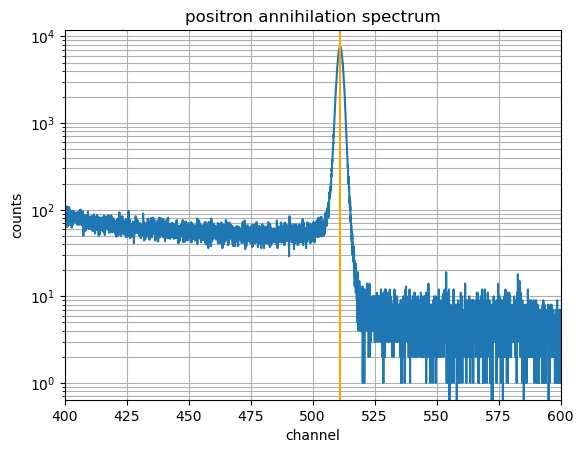

In [6]:
spectrum.xr_spectrum().plot(yscale='log')
plt.xlim([400,600])
plt.axvline(511, color='orange')
plt.grid(True, which='both')
plt.title('positron annihilation spectrum')
plt.xlabel('channel')
plt.ylabel('counts')